In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [202]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


# 1. Dataset Loading & Overview

In [203]:
df.shape

(2640, 12)

In [204]:
df.columns.tolist()

['Year',
 'Month',
 'Region',
 'Model',
 'Estimated_Deliveries',
 'Production_Units',
 'Avg_Price_USD',
 'Battery_Capacity_kWh',
 'Range_km',
 'CO2_Saved_tons',
 'Source_Type',
 'Charging_Stations']

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [206]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


*The Tesla EV Deliveries and Production dataset was loaded into a Pandas DataFrame for analysis. Basic information such as dataset dimensions, column names, data types, and summary statistics were examined to understand the structure and characteristics of the data before further processing.*

# 2. Data Cleaning

In [207]:
# Check missing values
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [208]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


*The dataset was checked for missing values and duplicate records to ensure data quality. No significant issues were found, making the dataset suitable for exploratory analysis and model development.*

# 3. Exploratory Data Analysis (EDA)

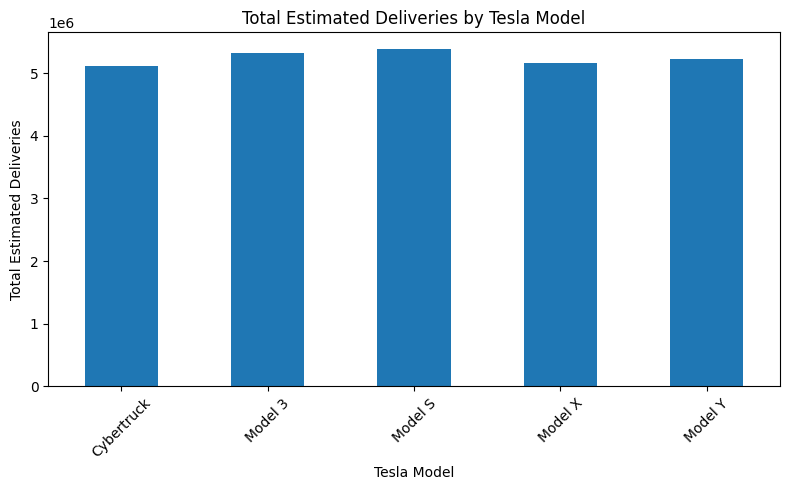

In [209]:
import matplotlib.pyplot as plt

# 1: Deliveries by Model
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8, 5))
model_deliveries.plot(kind='bar')
plt.title('Total Estimated Deliveries by Tesla Model')
plt.xlabel('Tesla Model')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*This visualization compares total estimated deliveries across Tesla models. It helps identify delivery distribution patterns and highlights differences in model-level performance.*

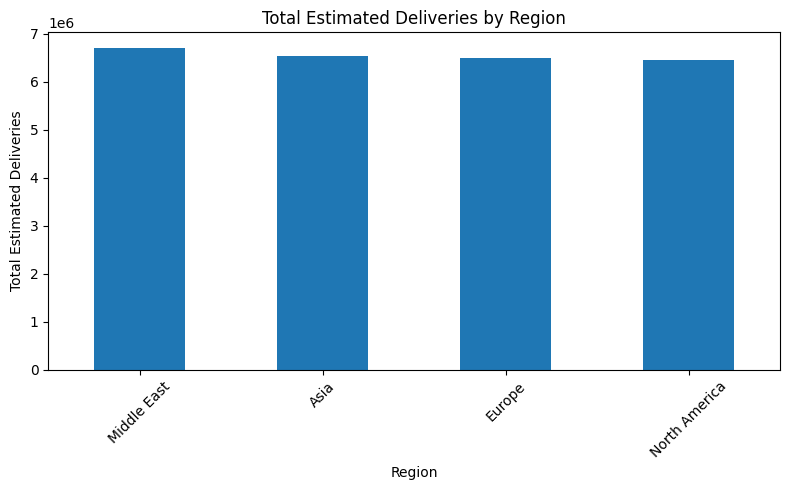

In [210]:
# 2: Deliveries by Region

region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_deliveries.plot(kind='bar')
plt.title('Total Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*This chart illustrates the distribution of vehicle deliveries across different regions. It provides insight into geographic demand and market performance.*

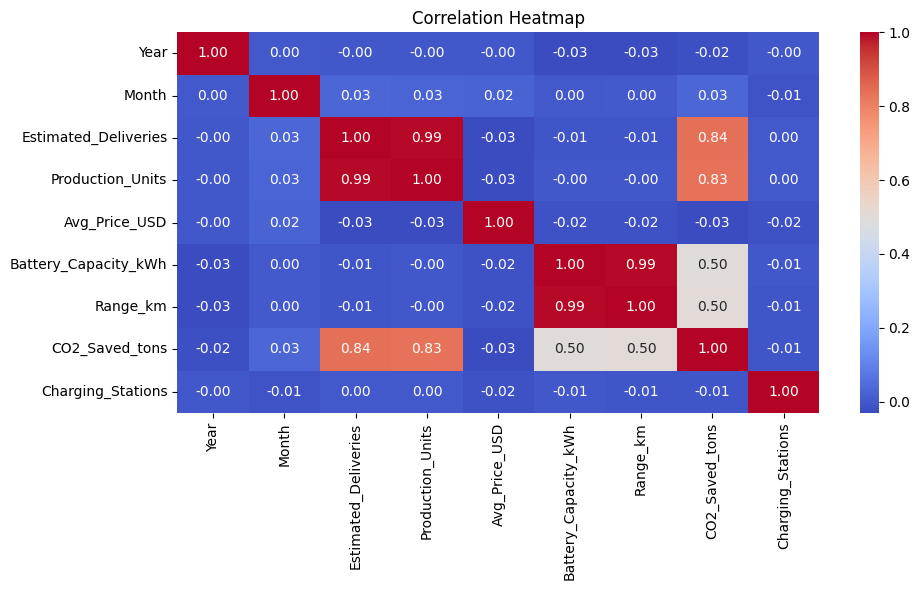

In [211]:
# 3: Correlation Heatmap

import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

*The correlation heatmap was used to examine relationships between numerical variables. A strong positive correlation between Production_Units and Estimated_Deliveries indicates that production volume is a key driver of deliveries.*

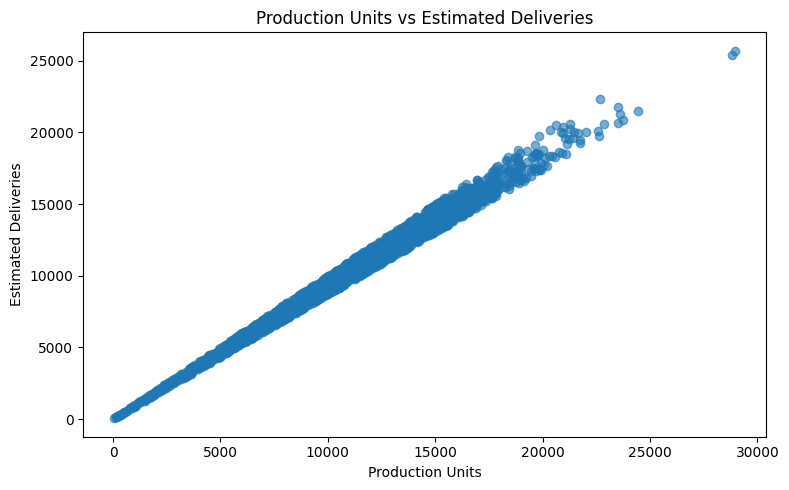

In [212]:
# 4: Production vs Deliveries Scatter Plot

plt.figure(figsize=(8,5))
plt.scatter(df['Production_Units'], df['Estimated_Deliveries'], alpha=0.6)
plt.title('Production Units vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

*The scatter plot shows the relationship between production units and estimated deliveries. The positive trend suggests that higher production levels are generally associated with higher delivery volumes.*

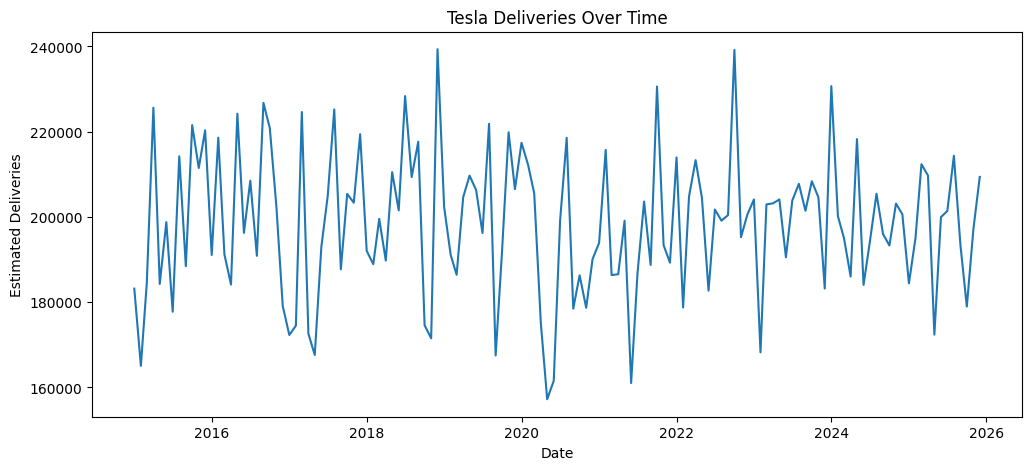

In [213]:
# 5: Time Trend Analysis

df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))

trend = df.sort_values('Date').groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))
plt.plot(trend.index, trend.values)
plt.title('Tesla Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

*The time series visualization highlights delivery trends over time. Observing these trends helps understand growth patterns and seasonal fluctuations in Tesla deliveries.*

# 4. Feature Engineering.

In [214]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

In [215]:
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

In [216]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)

In [217]:
df['Rolling_Mean_3'] = df['Estimated_Deliveries'].rolling(window=3).mean()

In [218]:
df['Deliveries_Lag1'] = df['Deliveries_Lag1'].fillna(
    df['Deliveries_Lag1'].mean()
)

df['Rolling_Mean_3'] = df['Rolling_Mean_3'].fillna(
    df['Rolling_Mean_3'].mean()
)

In [219]:
print(df[['Deliveries_Lag1','Rolling_Mean_3']].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


*The engineered features were verified to ensure that no missing values remained after feature creation. This step confirms that the dataset is ready for model training.*

# 5.  Model Building - Linear Regression

In [220]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

In [221]:
X = X.drop('Date', axis=1, errors='ignore')

In [222]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Deliveries_Lag1,Rolling_Mean_3
0,2015,1,2,4,10348,10835,85599.95,82,488,757.47,0,5991,2015-01-01,9921.649488,9921.864797
1,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,2015-01-01,10348.000000,9921.864797
2,2015,1,1,4,10835,11723,62939.81,120,718,1166.93,2,12301,2015-01-01,12446.000000,11209.666667
3,2015,1,3,3,8122,8343,62838.32,75,423,515.34,2,9297,2015-01-01,10835.000000,10467.666667
4,2015,1,2,2,13902,15423,94629.02,75,445,927.96,2,8666,2015-01-01,8122.000000,10953.000000


In [223]:
print(X.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations', 'Deliveries_Lag1', 'Rolling_Mean_3'],
      dtype='object')


In [224]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [225]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [226]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R² Score:", round(r2_lr, 4))

MAE: 317.93
RMSE: 386.69
R² Score: 0.9889


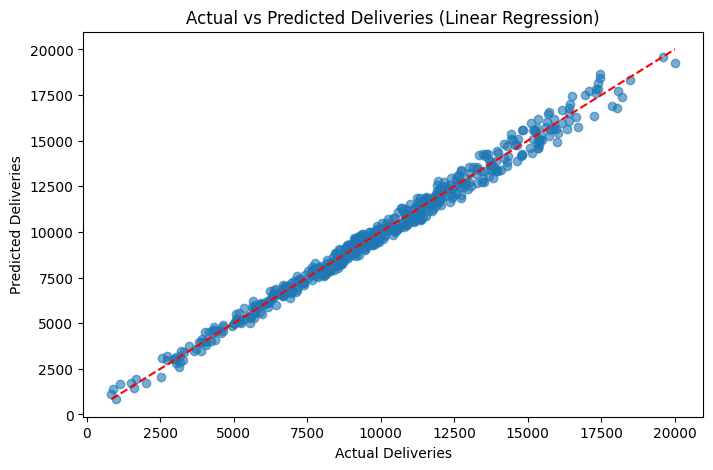

In [227]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title('Actual vs Predicted Deliveries (Linear Regression)')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.show()

*The Linear Regression model achieved strong predictive performance with a high R² score and low prediction error. The results indicate that the selected features effectively explain variations in delivery volumes.*

# 6. Cross Validation

In [228]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("R² Scores for each fold:")
print(cv_scores)

print("\nMean R²:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² Scores for each fold:
[0.99009945 0.9911265  0.99092691 0.99063511 0.98888589]

Mean R²: 0.990334772085499
Standard Deviation: 0.0008027811900615282


*Five-fold cross-validation was performed to assess the stability and generalization ability of the Linear Regression model. The model produced consistently high R² scores across all folds, indicating reliable performance.*

# 7. Random Forest Regression with Hyperparameter Tuning

In [229]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}


In [230]:
best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)

In [231]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Best Parameters:", grid_search.best_params_)
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 4))

Best Parameters: {'max_depth': None, 'n_estimators': 50}
MAE: 335.46
RMSE: 415.06
R² Score: 0.9872


*The Random Forest model achieved strong predictive performance with a high R² score. However, Linear Regression slightly outperformed Random Forest on this dataset, suggesting that the relationship between the features and target variable is largely linear.*

# 8. Feature Importance

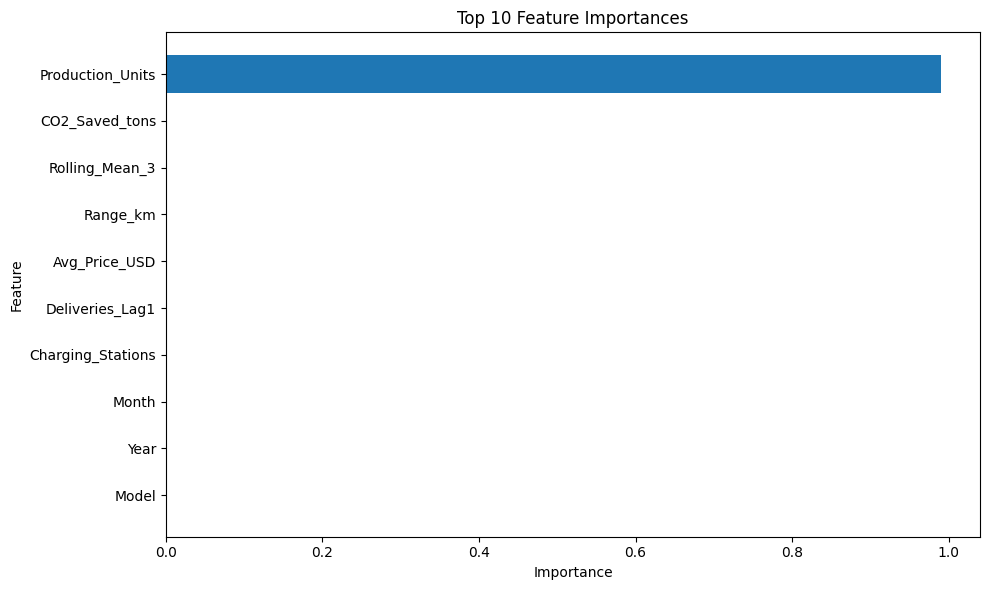

              Feature  Importance
4    Production_Units    0.990529
8      CO2_Saved_tons    0.001942
12     Rolling_Mean_3    0.001178
7            Range_km    0.001103
5       Avg_Price_USD    0.001053
11    Deliveries_Lag1    0.000946
10  Charging_Stations    0.000885
1               Month    0.000670
0                Year    0.000565
3               Model    0.000419


In [232]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

*The analysis shows that Production_Units is the most influential predictor of Estimated_Deliveries, contributing the majority of the model's predictive power. Other variables provide additional information but have significantly lower impact.*

# 9. Stationarity Testing using Augmented Dickey-Fuller (ADF) Test

In [233]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -24.662112249181465
p-value: 0.0

Critical Values:
1%: -3.432834129730111
5%: -2.862637500037151
10%: -2.56735423758412


*The obtained p-value was less than 0.05, indicating that the null hypothesis can be rejected. Therefore, the delivery series is stationary and suitable for forecasting applications.*

# 10. Forecast Table

In [234]:
forecast_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_lr
})

forecast_df['Error_%'] = (
    abs(forecast_df['Actual'] - forecast_df['Predicted'])
    / forecast_df['Actual']
) * 100

forecast_df.head(20)

,Actual,Predicted,Error_%
2112,9476,9063.528804,4.352799
2113,8179,8448.374747,3.293492
2114,14430,15095.699516,4.613302
2115,15912,16210.487814,1.875866
2116,15077,14598.067428,3.176577
2117,11280,11383.732099,0.919611
2118,4070,3964.099473,2.601979
2119,11636,11572.280772,0.547604
2120,12540,12514.509089,0.203277
2121,12717,11842.113838,6.879658


In [235]:
forecast_df = forecast_df.reset_index(drop=True)
forecast_df.head(20)

,Actual,Predicted,Error_%
0,9476,9063.528804,4.352799
1,8179,8448.374747,3.293492
2,14430,15095.699516,4.613302
3,15912,16210.487814,1.875866
4,15077,14598.067428,3.176577
5,11280,11383.732099,0.919611
6,4070,3964.099473,2.601979
7,11636,11572.280772,0.547604
8,12540,12514.509089,0.203277
9,12717,11842.113838,6.879658


*A forecast table was created to compare actual delivery values with model predictions. The error percentage was calculated to evaluate prediction accuracy and identify deviations between actual and predicted values.*

# 11. Model Comparison

In [236]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

comparison_df = comparison_df.round(4)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,317.9318,386.6947,0.9889
1,Random Forest,335.4629,415.0618,0.9872


A comparison of both models shows that Linear Regression achieved slightly better performance than Random Forest across all evaluation metrics. Linear Regression produced lower MAE and RMSE values while also achieving a higher R² score. This suggests that the relationship between the predictor variables and Tesla deliveries is largely linear, making Linear Regression the preferred model for this dataset.

# 12. Conclusion

An end-to-end machine learning pipeline was developed to forecast Tesla vehicle deliveries using historical production and delivery data. The project included data exploration, preprocessing, feature engineering, model training, cross-validation, hyperparameter tuning, and stationarity testing. Linear Regression achieved the best performance with an R² score of 0.9889, indicating strong predictive capability. Feature importance analysis identified Production_Units as the most influential factor affecting vehicle deliveries. The results demonstrate that production-related variables can effectively forecast Tesla delivery volumes with high accuracy.